In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.set_printoptions(threshold=np.inf)
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
#read data files

url_1 = "als_data.csv"
df = pd.read_csv(url_1, encoding="latin1")  # or utf-8 if latin1 fails

print(df.shape)        # (rows, columns)
print(df.info()) #no missing values indicated


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


(2223, 101)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2223 entries, 0 to 2222
Columns: 101 entries, ID to Urine.Ph_min
dtypes: float64(75), int64(26)
memory usage: 1.7 MB
None


In [3]:
#1.Remove any data that is not relevant to the patient’s ALS condition.
df.drop(["ID", "SubjectID"], axis=1, inplace=True)

#missing = df.isnull()
#print(missing)
low_variance = df.var() < 0.01

# List column names that are near-constant
low_var_cols = low_variance[low_variance].index.tolist()

from pprint import pprint
pprint(low_var_cols)

['Albumin_range',
 'ALSFRS_Total_range',
 'AST.SGOT._range',
 'Bicarbonate_range',
 'Blood.Urea.Nitrogen..BUN._range',
 'bp_diastolic_range',
 'bp_systolic_range',
 'Calcium_median',
 'Calcium_range',
 'Chloride_range',
 'Creatinine_range',
 'Glucose_range',
 'hands_range',
 'Hematocrit_range',
 'Hemoglobin_range',
 'leg_range',
 'mouth_range',
 'Potassium_range',
 'pulse_range',
 'respiratory_range',
 'Sodium_range',
 'trunk_range']


In [4]:
#remove features that are near-constant
df.drop(["Albumin_range", "ALSFRS_Total_range", "AST.SGOT._range", \
         "Bicarbonate_range", "Blood.Urea.Nitrogen..BUN._range", \
         "bp_diastolic_range", "bp_systolic_range", "Calcium_median", \
         "Calcium_range", "Chloride_range", "Creatinine_range",\
         "Glucose_range", "hands_range", "Hematocrit_range",\
         "Hemoglobin_range", "leg_range", "mouth_range",\
         "Potassium_range", "pulse_range", "pulse_range",\
         "respiratory_range", "Sodium_range", "trunk_range"], axis=1, inplace=True)

In [5]:
# I noticed that there are a lot of Zeros in certain columns. 

# Calculate percentage of zeros for all numeric columns
percent_zeros = (df == 0).sum() / len(df) * 100

# List columns where >30% are zeros
cols_over_30pct_zeros = percent_zeros[percent_zeros > 5].index.tolist()

print("Columns with more than 30% zeros:", cols_over_30pct_zeros)

Columns with more than 30% zeros: ['ALSFRS_slope', 'hands_median', 'hands_min', 'leg_min', 'trunk_min']


In [6]:
#removing columns with frequent zeros
df.drop(["hands_min", "leg_min", "leg_max", "trunk_min", \
         "trunk_max", "ALSFRS_slope", "hands_median"], axis=1, inplace=True)

In [7]:
#print(df.dtypes)

In [8]:
# Convert all columns that can be numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Replace remaining zeros with median for all numeric columns
for col in df.select_dtypes(include='number'):
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)


In [9]:
# Calculate summary statistics
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Std": df.std(),
    "Skewness": df.skew(),
    "Kurtosis": df.kurt()})
print(df.shape) 
#print(summary)

(2223, 70)


In [10]:
# Flags
summary['High_Skew'] = summary['Skewness'].abs() > 1
summary['High_Kurtosis'] = summary['Kurtosis'] > 3
summary['Low_Variability'] = summary['Std'] / summary['Mean'].abs() < 0.05  # Std less than 5% of mean

# Show flagged variables
health_check = summary[(summary['High_Skew']) |\
(summary['High_Kurtosis']) | (summary['Low_Variability'])]
#print(health_check)


In [11]:
# Compute correlation matrix
corr_matrix = df.corr().abs()  # absolute correlation

# Threshold for “too high” correlation
threshold = 0.9

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation higher than threshold
high_corr_cols = [column for column in upper.columns if any(upper[column] > threshold)]

print("Columns with high correlation:", high_corr_cols)

Columns with high correlation: ['Hematocrit_median', 'Hematocrit_min', 'Platelets_min']


In [12]:
#remove highly correlated items leaving Hematocit_median
df.drop(["Hematocrit_min", "Platelets_min"], axis=1, inplace=True)

In [13]:
#2.Apply a standard scalar to the data.

# Initialize scaler
scaler = StandardScaler()

# Fit and transform the data
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame 
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

#print(scaled_df)

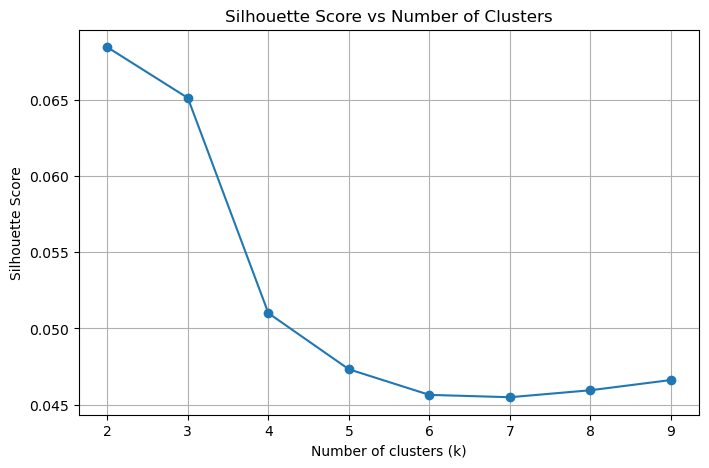

In [14]:
#3.Create a plot of the cluster silhouette score versus the number of clusters in a K-means cluster.

# Select numeric columns for clustering
X = scaled_df.select_dtypes(include=["number"])

# Range of k values to test
k_values = range(2, 10)

# Store silhouette scores
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(k_values)
plt.grid(True)
plt.show()

#4.Use the plot created in (3) to choose an optimal number of clusters for K-means. Justify your choice.

Based on the silhouette score plot, the optimal number of clusters is k = 2. At this point, the silhouette score reaches its maximum, indicating that data points are tightly grouped within their clusters and well-separated from other clusters. Increasing k beyond 2 reduces the silhouette score, meaning additional clusters don’t improve clustering quality and may even cause overfitting.

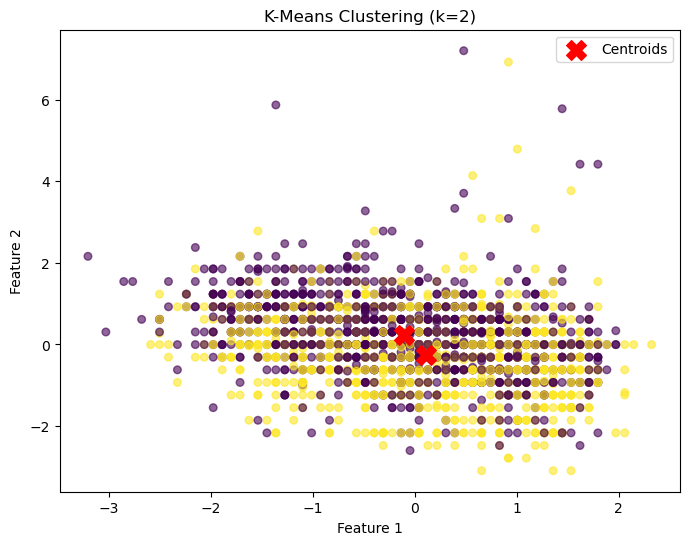

In [15]:
#5.Fit a K-means model to the data with the optimal number of clusters chosen in part (4).

# Fit KMeans with k=
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

# Get cluster centers
centers = kmeans.cluster_centers_

# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap="viridis", s=30, alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="X", label="Centroids")
plt.title("K-Means Clustering (k=2)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [16]:
#6.Fit a PCA transformation with two features to the scaled data.

# Fit PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df)

# Convert to DataFrame 
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative variance explained:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.1002419 0.0749783]
Cumulative variance explained: 0.17522020085621154


In [17]:
# Fit PCA 
pca = PCA()
pca.fit(scaled_df)  

# Explained variance ratio per component
explained_var = pca.explained_variance_ratio_

# Cumulative variance
cumulative_var = np.cumsum(explained_var)

# Print 
#for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), start=1):
    #print(f"PC{i}: {ev:.3f}, Cumulative: {cv:.3f}")

#using 68 features would capture 100% of the variance

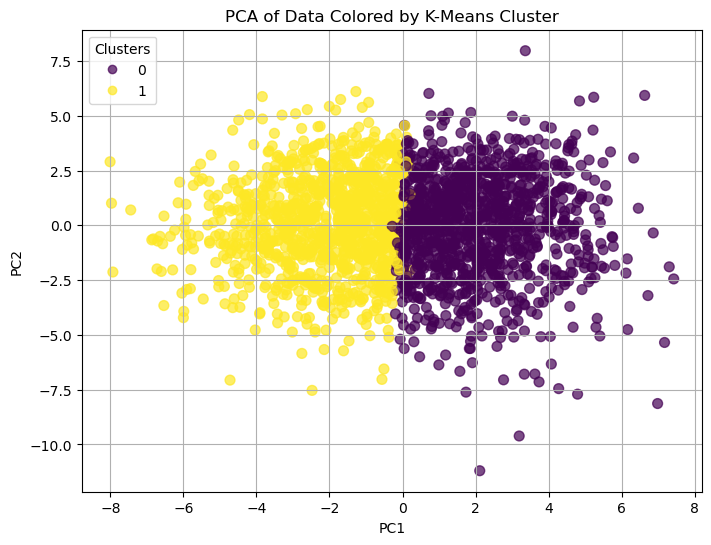

In [18]:
#7.Make a scatterplot the PCA transformed data coloring each point by its cluster value.

pca_df["Cluster"] = labels  # add cluster labels

# Scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=50,
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Data Colored by K-Means Cluster")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True)
plt.show()

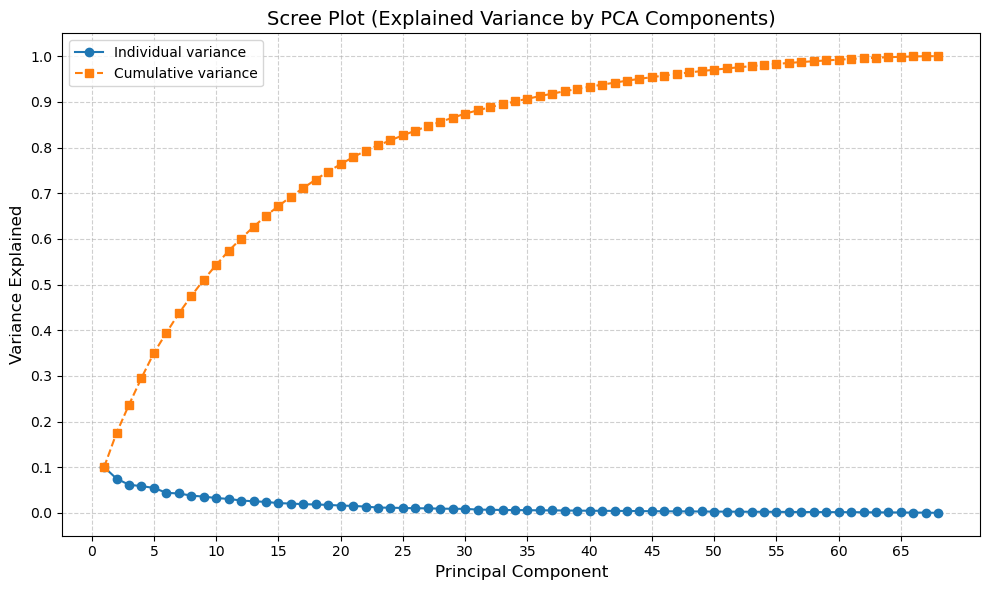

In [20]:
# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot
plt.figure(figsize=(10, 6))
components = np.arange(1, len(explained_var) + 1)

plt.plot(components, explained_var, 'o-', label='Individual variance')
plt.plot(components, cumulative_var, 's--', label='Cumulative variance')

# Cleaner x-axis ticks: every 5th component
plt.xticks(np.arange(0, len(components) + 1, 5))
plt.yticks(np.arange(0, 1.05, 0.1))

plt.title('Scree Plot (Explained Variance by PCA Components)', fontsize=14)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Variance Explained', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

#8.Summarize your results and make a conclusion.
It seems that k-means may not have worked well for this dataset. The data doesn’t appear to have strong natural clusters. Additionally, projecting the data with PCA only captured about 17.5% of the variance. Incorporating domain knowledge to identify and remove noisy or irrelevant features could help improve clustering results.